# Finite Difference Methods
Finite difference methods can be utilized to approximately evaluate derivatives and integrals. They are also useful in solving numerical differential equations. In these cases, one only needs to know the function values at the desired points.

## Derivatives 

1st-order derivative by definition: $df(x)/dx \equiv \lim_{h\rightarrow 0}\frac{f(x+h)-f(x)}{h}.$

Forward difference: $df(x)/dx \sim \frac{f(x+h)-f(x)}{h} + O(h).$

Backward difference: $df(x)/dx \sim \frac{f(x)-f(x-h)}{h} + O(h).$

Central differnce: $df(x)/dx \sim \frac{f(x+h)-f(x-h)}{2h} + O(h^2).$

Central difference for 2nd-order derivative: $d^2f(x)/dx^2 \sim \frac{f(x+h) -2f(x) +f(x-h)}{h^2} + O(h^2)$.


In [1]:
# Import numpy and matplotlib for scientific calculation/visualization.
import numpy as np
import matplotlib.pyplot as plt

**Example.** Use the central difference method to compute the 1st-order derivative of $f(x) = 1+\frac{1}{2}\tanh{(2x)}$. Plot the numertical values of $f'(x)$ in the range $-2\le x \le 2$, and compare the results to the exact one $f'(x)= \frac{1}{\cosh^2(2x)}$.

In [2]:
# Import the math library to evaluate tanh and cosh:
from math import tanh, cosh

# Note: the following functions take only a floating-point scalar as input.
# They return only a single scalar value as well.
def f(x):
    return 1+0.5*tanh(2*x)

def fprime(x, h=0.1):
    return (f(x+h)-f(x-h))/(2*h)

h=0.1
print('h=',h)
print('error:', fprime(0) - 1/cosh(2*0)**2,'\n')

h = 0.001
print('h=',h)
print('error:', fprime(0, h) - 1/cosh(2*0)**2)

h= 0.1
error: -0.013123398875479975 

h= 0.001
error: -1.333331166808449e-06


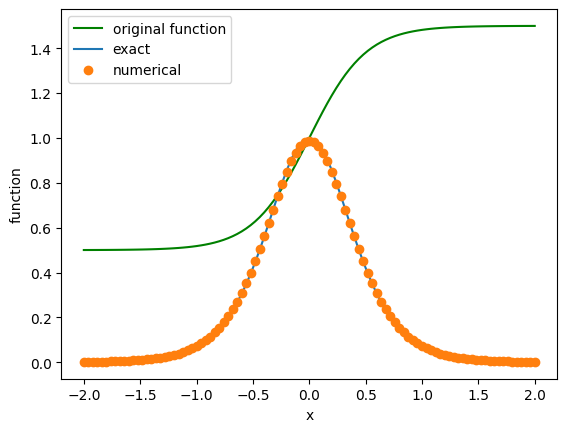

In [6]:
# discretize the x-axis:
a = -2
b = 2
n = 101 #number of grid points for Plotting.

# spacing between x-grid for plotting:
# delta_ x = (b-a)/(n-1)

# A numpy array object for the discretized x-axis:
x = np.linspace(a,b,n)

# Exact derivatives:
fp_exact = 1/np.cosh(2*x)**2

# Numerical results:

h = 0.1 #step size for evaulating finite difference.
### NOTE: h does NOT need to be equal to delta_x.
'''
fp_numerical = []
for ii in range(len(x)):
    xi = x[ii]
    fp_numerical.append(fprime(xi,h))

#Convert it to an numpy array:
fp_numerical = np.array(fp_numerical)
'''
f_prime_np = np.vectorize(fprime)
fp_numerical = f_prime_np(x)

f_x = np.vectorize(f)
fofx = f_x(x)

plt.plot(x,fofx,'g',label='original function')
plt.plot(x,fp_exact, label='exact')
plt.plot(x,fp_numerical,'o', label='numerical')

plt.legend()
plt.xlabel('x')
plt.ylabel('function')
plt.show()

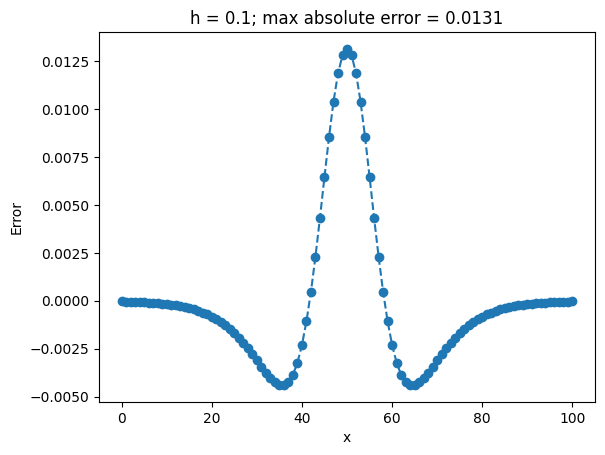

In [7]:
plt.plot(fp_exact - fp_numerical,'--o')

#Note: For forward difference,
#we expect the error to be correlated with h and f"(x).

maxabserror = round(max(abs(fp_exact - fp_numerical)),4)
# Use formatted print:
plt.title(f'h = {h}; max absolute error = {maxabserror}')

plt.xlabel('x')
plt.ylabel('Error')
plt.show()

## Integration

### Left rectangle rule
$\int_a^b f(x) dx \simeq \sum_{i=0}^{n-1} c_i f(x_i)$.

$c_i = h\{1,1,...,1,0\}$.

Total error $\sim O(h)$.

### Trapezoid rule
$\int_a^b f(x) dx \simeq \sum_{i=0}^{n-1} c_i f(x_i)$. 

$c_i = h\{\frac1{2},1,...,1,\frac1{2}\}$.

Total error $\sim O(h^2)$.

### Simpson rule
$\int_a^b f(x) dx \simeq \sum_{i=0}^{n-1} c_i f(x_i)$. 

$c_i = \frac{h}{3}\{1,4,2,4, ...,2,4,1\}$.

Total error $\sim O(h^4)$.

**Note:** $n$ should be an odd number for the Simpson rule. Your Simpson rule function should check this first.

**Example.** Plot the function $f(x) = (e^{-|x-2|})^2$ in the range $-2\le x \le 6$. Use the left-rectangle and trapezoid rules to numerically evaluate the integral $\int^{b=4}_{a=2} f(x) dx$. You can benchmark your trapeziod rule result with the *np.trapezoid()* function.

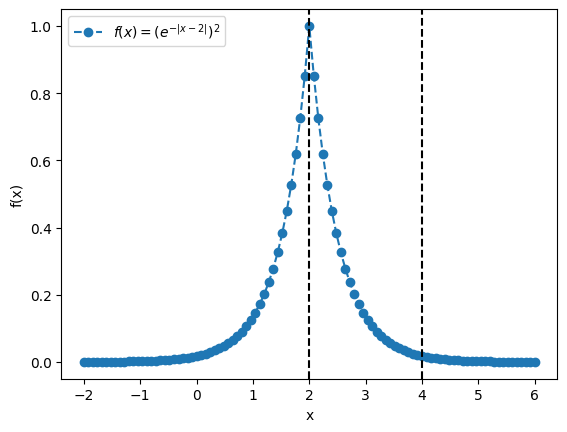

In [11]:
# Visualize the function first:

# Note: the function can take a numpy array as input.
def f(x):
    return np.exp(-abs(x-2))**2

a = -2
b = 6
n = 101
# delta_x = (b-a)/(n-1).
# Here, delta_x and h are essentially the same.

x=np.linspace(a,b,n)

plt.plot(x,f(x),'--o', label='$f(x) = (e^{-|x-2|})^2$')

plt.xlabel('x')
plt.ylabel('f(x)')

# Add a vertical line passing x=2 and x=4.
plt.axvline(x=2,c='k',ls='--')
plt.axvline(x=4,c='k',ls='--')

plt.legend()
plt.show()

In [12]:
# Define the integration rules:

def rectangle(f, a, b, n):
    h = (b-a)/(n-1)
    x = a + np.arange(n)*h
    #note: np.arange(n) gives np.array([0,1,2, ..., n-1]). 
    #equivalently: x = np.linspace(a,b,n)
    '''
    c = np.ones(n);
    c[-1] = 0
    
    contribution = h*c*f(x) #vectorization
    '''
    c = h*np.ones(n)
    c[-1]=0
    contribution = c*f(x)
    return np.sum(contribution)

def trapezoid(f, a, b, n):
    h = (b-a)/(n-1)
    x = a + np.arange(n)*h
    #equivalently: x = np.linspace(a,b,n)

    c = np.ones(n);
    c[0] = 0.5
    c[-1] = 0.5
    
    contribution = h*c*f(x)
    return np.sum(contribution)

In [15]:
# Perform numerical integration:
n = 21
a = 2
b = 4
h = (b-a)/(n-1)

I_rectangle = rectangle(f, a, b, n)
I_trapezoid = trapezoid(f, a, b, n)
I_exact = 0.5*(1- 1/np.e**4)

print('finite difference step size h:', h)
print('h:', h)
print('h^2:', h**2, '\n')

print('Exact value: ', I_exact)
print('rectangle rule:', I_rectangle, 'error=', I_rectangle-I_exact)
print('trapezoid rule:', I_trapezoid, 'error=', I_trapezoid-I_exact)

finite difference step size h: 0.1
h: 0.1
h^2: 0.010000000000000002 

Exact value:  0.4908421805556329
rectangle rule: 0.5415614494904287 error= 0.050719268934795836
trapezoid rule: 0.4924772314348654 error= 0.0016350508792324914


In [17]:
# Use numpy built-in trapezoid function to check your integration:
n = 21
a = 2
b = 4
h = (b-a)/(n-1)

x = a + np.arange(n)*h
# equivalently: 
# x = np.linspace(a,b,n)

# Note about the use of np.trapezoid:
# np.trapezoid(y, x=None, dx=1.0, axis=-1)
I_nptrapz = np.trapezoid(f(x), dx = h)
print('Numpy trapzoid rule:', I_nptrapz)
print('Difference between the two: ', I_trapezoid - I_nptrapz)

Numpy trapzoid rule: 0.49247723143486544
Difference between the two:  -5.551115123125783e-17


### Beyond the leading order error
The total numerical integration error can depend on the step size $h$, the total integraion intevral ($= x_{n-1}-x_0$, or $b-a$), and the derivatives of the function itself.

**In practice**, one should use more sampling points, or use higher-order integration methods (eg. the Simpson rule), until the required accuracy is acheved.

## Simple Exercises.

**Exercise 1.**

Use the central difference method to compute the 1st-order derivative of $f(x) = \sin(x)$. Plot the numertical values of both $f(x)$ and $f'(x)$ in the range $-\pi \le x \le \pi$. Compare your results to the exact function $f'(x)= -\cos(x)$. What is the maximum absolute error you get (as a function of $h$)?

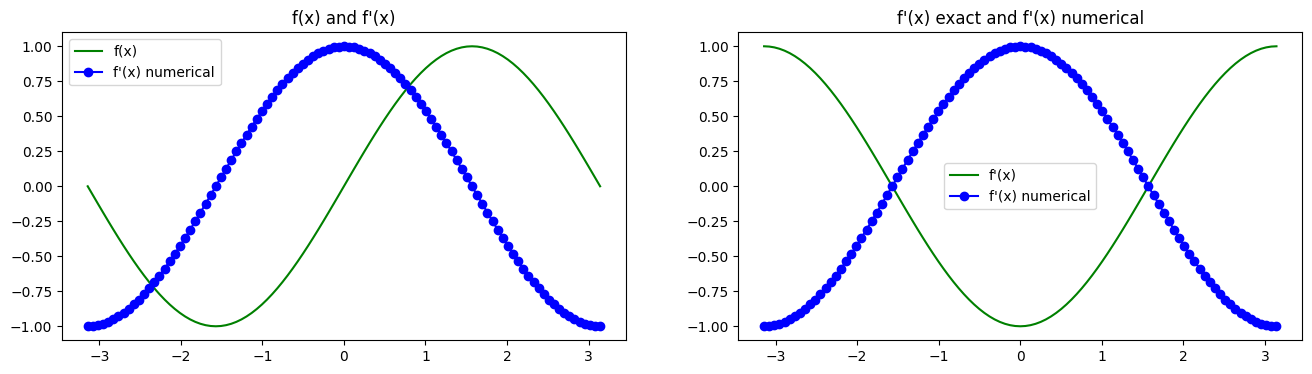

In [39]:
# Your code starts here:
def fp_cl(x, h):
    return (np.sin(x+h) - np.sin(x-h))/(2*h)

a = -np.pi
b = np.pi
n = 101
h = 0.01
x = np.linspace(a, b, n)

f = np.sin(x)
fp_num = fp_cl(x, h)
fp_exact = -np.cos(x)

fig, axes = plt.subplots(1,2, figsize=(16,4))

axes[0].plot(x,f,c='g',label='f(x)')
axes[0].plot(x,fp_num,c='b',marker='o',label="f'(x) numerical")
axes[0].set_title("f(x) and f'(x)")
axes[0].legend()

axes[1].plot(x,fp_exact,c='g',label="f'(x)")
axes[1].plot(x,fp_num,c='b',marker='o',label="f'(x) numerical")
axes[1].set_title("f'(x) exact and f'(x) numerical")
axes[1].legend()

**Exercise 2.** Write a Simpson rule function to evaluate the above example in the Integration section.

In [29]:
# Your code starts here:
def Simpson(f, a, b, n):
    if n % 2 == 0:
        print('Error: n must be an odd number!')
    else:
        h = (b-a)/(n-1)
        x = np.linspace(a,b,n)
        print(f'$h = {h}, h^4 = {h**4}')
    
        c = np.ones(n)
        for i in range(len(c)):
            if i % 2 == 0:
                c[i] = 2
            else:
                c[i] = 4
        c[0], c[-1] = 1, 1

        contribution = (h/3)*c*f(x)
        return np.sum(contribution)

I_simpson = Simpson(f, 2, 4, 101)
print(I_simpson)
print("The difference between Simpson's rule and the exact value: ", I_exact - I_simpson)

$h = 0.02, h^4 = 1.6e-07
0.49084218753516995
The difference between Simpson's rule and the exact value:  -6.9795370594150086e-09
